In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [215]:
pd.set_option('display.max_columns', None)

In [216]:
df_renewal = pd.read_csv('../../../data/interim/renewal_calls_cleaned.csv')
df_email = pd.read_csv('../../../data/interim/emails_cleaned.csv')
df_cc = pd.read_csv('../../../data/interim/cc_calls_cleaned.csv')
df_billings = pd.read_csv('../../../data/interim/billings_cleaned.csv')

In [217]:
df_cc.info()

<class 'pandas.DataFrame'>
RangeIndex: 31636 entries, 0 to 31635
Data columns (total 30 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   contact_id                                31636 non-null  float64
 1   call_date                                 31636 non-null  str    
 2   direction                                 31636 non-null  str    
 3   cc_care_package                           31636 non-null  str    
 4   cc_care_package_discussed                 31636 non-null  str    
 5   cc_urgency_getting_on_site                31636 non-null  str    
 6   cc_external_consultant                    31636 non-null  str    
 7   cc_agent_cross_sell_attempt               31636 non-null  str    
 8   cc_customer_issues_concerns               31636 non-null  str    
 9   cc_business_struggles_financial_hardship  31636 non-null  str    
 10  cc_call_initiated_by                      316

In [218]:
df_merged = (
    df_billings
    .merge(df_renewal, on='co_ref', how='left', suffixes=('', '_renewal'))
    .merge(df_email, on='co_ref', how='left', suffixes=('', '_email'))
    .merge(df_cc, on='co_ref', how='left', suffixes=('', '_cc'))
)

In [219]:
df_merged.shape

(668008, 130)

In [220]:
for col in df_merged.columns:
    print(df_merged[col].value_counts(dropna=False))
    print(df_merged[col].isnull().sum())
    print("-" * 50)

co_ref
VU9662    3968
AD1657    1610
DB3207    1292
AA0994    1287
FW0890     900
          ... 
XQ5674       1
MH5611       1
LQ9360       1
EX0639       1
XU6585       1
Name: count, Length: 47814, dtype: int64
0
--------------------------------------------------
renewal_month
2025-10-01    21429
2025-11-01    21214
2024-11-01    20904
2024-10-01    20506
2025-09-01    19763
2024-09-01    19288
2024-06-01    19064
2025-01-01    18402
2024-05-01    18228
2025-06-01    18111
2025-05-01    18062
2023-11-01    18056
2023-10-01    17873
2026-01-01    17650
2025-07-01    17613
2026-02-01    17569
2024-07-01    17436
2023-09-01    16961
2025-02-01    16928
2024-08-01    16836
2023-06-01    16728
2025-08-01    16650
2026-05-01    16192
2023-05-01    16080
2024-01-01    15590
2023-07-01    15499
2024-02-01    14685
2024-04-01    14473
2023-08-01    14292
2025-04-01    14225
2025-12-01    13923
2023-01-01    13903
2024-12-01    13762
2025-03-01    13443
2023-02-01    13351
2023-04-01    12994


In [221]:
df_merged

,co_ref,renewal_month,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,proforma_world_pay_token,proforma_date,current_anchorings,payment_timeframe,registration_date,proforma_account_stage,proforma_audit_status,current_auto_renewal_flag,current_world_pay_token,renewal_score_at_release,proforma_membership_status,proforma_approved_lists,tenure_years,band,prospect_renewal_date,starting_net,starting_vat,starting_gross,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,prospect_outcome,payment_method,total_amount,tenure_group,last_renewal,last_band,last_total_net_paid,last_connections,anchor_group,renewal_year,is_first_year,has_discount,discount_pct,call_id,call_direction,call_date,membership_renewal_decision,serious_complaint,other_complaint,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,call_reschedule_request,agent_flagged_membership_status_alert,agent_renewal_initiation,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_value_comparison,competitor_benefits_mentioned,topic_introduced_by,percentage_price_increase_mentioned,monetary_price_increase_mentioned,price_range_mentioned,customer_asked_for_justification,customer_response,desire_to_cancel,discount_offered,call_number,time_to_renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,year,sentiment_score_missing,contact_id,call_date_cc,direction,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_call_initiated_by,cc_questionnaire_completion,cc_chasing_response,cc_issues_within_questionnaire,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_contractor_sentiment,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained
0,VT6174,2024-11-01,8.0,42.5,799.0,9,9,7.5,9.0,True,True,2024-09-06,0,0,2021-11-05,Published,Accredited,y,y,26.0,Accredited,1,3,Band C1,2024-11-05,919,183.8,1102.8,664,120,135,664.0,0.0,135,Won,Card,799.0,3,2023-11-01,Band B,664.0,1,1,2024,0,0,0.0,6.920000e+11,OUT_BOUND,2026-01-13,No,No,No,No,No,No,Yes,No,Yes,No,No,No,No,Not Applicable,Not Applicable,Not Discussed,No,No,Not Discussed,No,Neutral,Not Discussed,No,5.0,pre_renewal,Not Discussed,Not Discussed,Not Discussed,No,No,Yes,neutral,50.0,No,Yes,No,Accredited,No,No,0.0,Not Discussed,Not Discussed,0.0,Not Discussed,No,No,No,No,Not Discussed,2025.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,VT6174,2024-11-01,8.0,42.5,799.0,9,9,7.5,9.0,True,True,2024-09-06,0,0,2021-11-05,Published,Accredited,y,y,26.0,Accredited,1,3,Band C1,2024-11-05,919,183.8,1102.8,664,120,135,664.0,0.0,135,Won,Card,799.0,3,2023-11-01,Band B,664.0,1,1,2024,0,0,0.0,6.870000e+11,OUT_BOUND,2025-11-05,No,No,Yes,No,No,No,No,Yes,Yes,No,No,No,No,Not Applicable,Not Discussed,Not Discussed,No,No,Not Discussed,N

In [222]:

for col in df_merged.columns:
    if 'date' in col or 'month' in col:
        df_merged[col] = pd.to_datetime(df_merged[col])
        print(col)
        print(df_merged[col])
        

renewal_month
0        2024-11-01
1        2024-11-01
2        2024-11-01
3        2024-11-01
4        2024-11-01
            ...    
668003   2023-09-01
668004   2023-08-01
668005   2023-08-01
668006   2023-07-01
668007   2023-07-01
Name: renewal_month, Length: 668008, dtype: datetime64[us]
proforma_date
0        2024-09-06
1        2024-09-06
2        2024-09-06
3        2024-09-06
4        2024-09-06
            ...    
668003   2023-07-06
668004   2023-06-07
668005   2023-06-07
668006   2023-05-10
668007   2023-05-10
Name: proforma_date, Length: 668008, dtype: datetime64[us]
registration_date
0        2021-11-05
1        2021-11-05
2        2021-11-05
3        2021-11-05
4        2021-11-05
            ...    
668003   2020-09-15
668004   2020-08-03
668005   2020-08-03
668006   2020-07-08
668007   2020-07-08
Name: registration_date, Length: 668008, dtype: datetime64[us]
prospect_renewal_date
0        2024-11-05
1        2024-11-05
2        2024-11-05
3        2024-11-05
4        20

In [223]:
open_prospects = df_merged[df_merged['prospect_outcome'] == 'Open']

In [224]:
open_prospects['prospect_outcome'].value_counts()

prospect_outcome
Open    37604
Name: count, dtype: int64

In [225]:
df_filtered = df_merged[
    (
        # Group all date logic together first
        (
            ((df_merged['prospect_renewal_date'] - df_merged['call_date']).dt.days.between(0, 14)) |
            ((df_merged['prospect_renewal_date'] - df_merged['call_date_cc']).dt.days.between(0, 14))
        )
    ) & 
    (df_merged['prospect_outcome'] != 'Open') # Now applies to both date conditions
]

In [226]:
df_filtered.shape

(78325, 130)

In [227]:
print(df_filtered['prospect_outcome'].value_counts())

prospect_outcome
Won        68967
Churned     9358
Name: count, dtype: int64


In [228]:
for col in df_filtered.columns:
    print(df_filtered[col].value_counts(dropna=False))
    print(df_filtered[col].isnull().sum())
    print("-" * 50)

co_ref
AA0994    243
RE6328    102
VU9662     93
GK6414     80
XB6908     78
         ... 
MR9914      1
AH3239      1
NS9452      1
IK6353      1
HG7200      1
Name: count, Length: 21206, dtype: int64
0
--------------------------------------------------
renewal_month
2025-02-01    4530
2025-10-01    4279
2025-09-01    4257
2025-01-01    4216
2024-10-01    4128
2024-11-01    4121
2025-11-01    4069
2024-09-01    3880
2024-07-01    3730
2024-05-01    3675
2025-03-01    3614
2024-08-01    3423
2025-07-01    3275
2025-08-01    3208
2024-06-01    3161
2024-12-01    2920
2025-06-01    2902
2024-04-01    2711
2025-05-01    2673
2025-12-01    2548
2026-01-01    2516
2025-04-01    2473
2026-02-01    2016
Name: count, dtype: int64
0
--------------------------------------------------
sustainability_score
8.0    44439
9.5    24068
9.0     9818
Name: count, dtype: int64
0
--------------------------------------------------
total_renewal_score_new
44.0    9954
43.0    7409
45.5    7115
45.0    6731


In [229]:
# Columns to remove: identifiers, dates used for filtering, derived scores that may cause leakage, proforma statuses, and other non-beneficial columns
columns_to_drop = [
    'co_ref', 'contact_id', 'call_id', 'proforma_date', 'call_date', 'call_date_cc', 
    'registration_date', 'prospect_renewal_date', 'starting_vat', 'starting_gross',
    'proforma_world_pay_token', 'current_world_pay_token', 'proforma_audit_status',
    'proforma_approved_lists', 'proforma_account_stage', 'sentiment_score_missing',
    'year', 'renewal_year', 'direction'
]

df_filtered = df_filtered.drop(columns=columns_to_drop)

In [230]:
num_cols = []

for col in df_filtered.columns:
    if df_filtered[col].dtype in ['int64', 'float64']:
        print(f"Column: {col}")
        num_cols.append(col)
        print(df_filtered[col].value_counts())
        print(f"Null values: {df_filtered[col].isnull().sum()}")
        print("-" * 50)

Column: sustainability_score
sustainability_score
8.0    44439
9.5    24068
9.0     9818
Name: count, dtype: int64
Null values: 0
--------------------------------------------------
Column: total_renewal_score_new
total_renewal_score_new
44.0    9954
43.0    7409
45.5    7115
45.0    6731
44.5    6652
43.5    6314
42.0    5026
42.5    3345
41.0    3198
41.5    2544
46.5    2364
32.0    1972
33.0    1883
46.0    1783
34.0    1454
32.5    1439
40.5    1438
40.0    1397
35.0    1125
33.5    1007
34.5     937
31.0     937
39.5     754
31.5     704
39.0     315
38.5     166
36.0     133
35.5      77
30.5      59
36.5      55
38.0      29
37.5       8
37.0       1
Name: count, dtype: int64
Null values: 0
--------------------------------------------------
Column: last_years_price
last_years_price
599.00     3454
999.00     3427
799.00     2901
949.00     2341
579.00     2242
           ... 
702.00        1
813.60        1
833.40        1
1592.10       1
258.75        1
Name: count, Length: 141

In [231]:
def fill_numericals_refined(df, num_cols):
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            
            # 1. Logical Zero Fill: These columns likely mean "None" if NaN
            zero_fill = ['call_number', 'crm_agent_chase_count', 'crm_auto_renewal_status']
            if any(x in col for x in zero_fill):
                df[col] = df[col].fillna(0)
                continue

            # 2. Sentiment Score Logic: Neutral point is 50.0
            # If sentiment is missing, we shouldn't assume perfection (90) or failure (0).
            # Filling with the median is safest for these specific distributions.
            sentiment_cols = ['sentiment_score', 'sentiment_start', 'sentiment_end', 'sentiment_overall']
            if any(x in col for x in sentiment_cols):
                df[col] = df[col].fillna(df[col].median())
                continue

            # 3. General Distribution Logic for any other columns
            skewness = df[col].skew()
            if abs(skewness) > 1:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mean())

In [232]:
fill_numericals_refined(df_filtered, num_cols)

In [233]:
for col in df_filtered.columns:
    if df_filtered[col].dtype in ['int64', 'float64']:
        print(f"Column: {col}")
        print(df_filtered[col].value_counts())
        print(f"Null values: {df_filtered[col].isnull().sum()}")
        print("-" * 50)

Column: sustainability_score
sustainability_score
8.0    44439
9.5    24068
9.0     9818
Name: count, dtype: int64
Null values: 0
--------------------------------------------------
Column: total_renewal_score_new
total_renewal_score_new
44.0    9954
43.0    7409
45.5    7115
45.0    6731
44.5    6652
43.5    6314
42.0    5026
42.5    3345
41.0    3198
41.5    2544
46.5    2364
32.0    1972
33.0    1883
46.0    1783
34.0    1454
32.5    1439
40.5    1438
40.0    1397
35.0    1125
33.5    1007
34.5     937
31.0     937
39.5     754
31.5     704
39.0     315
38.5     166
36.0     133
35.5      77
30.5      59
36.5      55
38.0      29
37.5       8
37.0       1
Name: count, dtype: int64
Null values: 0
--------------------------------------------------
Column: last_years_price
last_years_price
599.00     3454
999.00     3427
799.00     2901
949.00     2341
579.00     2242
           ... 
702.00        1
813.60        1
833.40        1
1592.10       1
258.75        1
Name: count, Length: 141

In [234]:
df_filtered = df_filtered.fillna('Unknown')

In [235]:
df_filtered.shape

(78325, 111)

In [236]:
for col in df_filtered.columns:
    print(df_filtered[col].value_counts(dropna=False))
    print(df_filtered[col].isnull().sum())
    print("-" * 50)

renewal_month
2025-02-01    4530
2025-10-01    4279
2025-09-01    4257
2025-01-01    4216
2024-10-01    4128
2024-11-01    4121
2025-11-01    4069
2024-09-01    3880
2024-07-01    3730
2024-05-01    3675
2025-03-01    3614
2024-08-01    3423
2025-07-01    3275
2025-08-01    3208
2024-06-01    3161
2024-12-01    2920
2025-06-01    2902
2024-04-01    2711
2025-05-01    2673
2025-12-01    2548
2026-01-01    2516
2025-04-01    2473
2026-02-01    2016
Name: count, dtype: int64
0
--------------------------------------------------
sustainability_score
8.0    44439
9.5    24068
9.0     9818
Name: count, dtype: int64
0
--------------------------------------------------
total_renewal_score_new
44.0    9954
43.0    7409
45.5    7115
45.0    6731
44.5    6652
43.5    6314
42.0    5026
42.5    3345
41.0    3198
41.5    2544
46.5    2364
32.0    1972
33.0    1883
46.0    1783
34.0    1454
32.5    1439
40.5    1438
40.0    1397
35.0    1125
33.5    1007
34.5     937
31.0     937
39.5     754
31.5    

In [237]:
for col in df_filtered.columns:
    print(col)

renewal_month
sustainability_score
total_renewal_score_new
last_years_price
auto_renewal_score
status_scores
anchoring_score
tenure_scores
proforma_auto_renewal
current_anchorings
payment_timeframe
current_auto_renewal_flag
renewal_score_at_release
proforma_membership_status
tenure_years
band
starting_net
starting_membership_net
starting_package_net
starting_pqq_net
membership_net
package_net
pqqnet
prospect_outcome
payment_method
total_amount
tenure_group
last_renewal
last_band
last_total_net_paid
last_connections
anchor_group
is_first_year
has_discount
discount_pct
call_direction
membership_renewal_decision
serious_complaint
other_complaint
discussion_on_price_increase
renewal_impact_due_to_price_increase
discount_or_waiver_requested
call_reschedule_request
agent_flagged_membership_status_alert
agent_renewal_initiation
explicit_competitor_mention
explicit_switching_intent
mentioned_competitors
price_switching_mentioned
competitor_value_comparison
competitor_benefits_mentioned
topic_i

In [238]:
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 78325 entries, 6 to 665981
Columns: 111 entries, renewal_month to cc_contractor_complained
dtypes: bool(1), datetime64[us](1), float64(18), int64(13), str(78)
memory usage: 66.4 MB


In [239]:
df_filtered.head()

,renewal_month,sustainability_score,total_renewal_score_new,last_years_price,auto_renewal_score,status_scores,anchoring_score,tenure_scores,proforma_auto_renewal,current_anchorings,payment_timeframe,current_auto_renewal_flag,renewal_score_at_release,proforma_membership_status,tenure_years,band,starting_net,starting_membership_net,starting_package_net,starting_pqq_net,membership_net,package_net,pqqnet,prospect_outcome,payment_method,total_amount,tenure_group,last_renewal,last_band,last_total_net_paid,last_connections,anchor_group,is_first_year,has_discount,discount_pct,call_direction,membership_renewal_decision,serious_complaint,other_complaint,discussion_on_price_increase,renewal_impact_due_to_price_increase,discount_or_waiver_requested,call_reschedule_request,agent_flagged_membership_status_alert,agent_renewal_initiation,explicit_competitor_mention,explicit_switching_intent,mentioned_competitors,price_switching_mentioned,competitor_value_comparison,competitor_benefits_mentioned,topic_introduced_by,percentage_price_increase_mentioned,monetary_price_increase_mentioned,price_range_mentioned,customer_asked_for_justification,customer_response,desire_to_cancel,discount_offered,call_number,time_to_renewal,crm_accreditation_completed,crm_timely_completion,crm_progress_towards_accreditation,crm_delays_in_accreditation,crm_contractor_suggested_leave,crm_contractor_engagement,crm_contractor_sentiment,crm_contractor_sentiment_score,crm_dts_or_ssip_mentioned,crm_customer_payment_intention,crm_competitors_mentioned,crm_membership_level,crm_platform_issues_raised,crm_agent_chased_contractor,crm_agent_chase_count,crm_accreditation_issues,crm_membership_overdue,crm_auto_renewal_status,crm_dissatisified_with_renewal_price,crm_customer_complained,crm_refund_mentioned,crm_negative_customer_experience,crm_dissatisfaction_with_support,crm_financial_hardship_mentioned,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,cc_call_initiated_by,cc_questionnaire_completion,cc_chasing_response,cc_issues_within_questionnaire,cc_login_issues,cc_platform_issues,cc_dissatisfaction_time_to_complete,cc_process_complexity_concerns,cc_questions_harder_than_expected,cc_dissatisfaction_support,cc_contractor_sentiment,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained
6,2025-08-01,8.0,41.5,799.0,9,9,7.5,8.0,True,0,0,y,24.5,Accredited,1,Band C1,919,664,120,135,664.0,0.0,135,Won,Card,799.0,1,2025-08-09,Band C1,919.0,0,1,1,0,0.0,OUT_BOUND,No,No,No,No,No,No,No,No,Yes,No,No,No,No,Not Applicable,Not Applicable,Not Discussed,No,No,Not Discussed,No,Neutral,Renewed,No,1.0,pre_renewal,No,Not Discussed,Yes,No,No,Yes,neutral,50.0,No,Not Discussed,No,Accredited,No,Yes,1.0,No,Yes,0.0,Yes,No,No,No,No,Not Discussed,Express,Yes,No,No,No,No,No,Agent,No,No,No,No,No,No,No,No,No,Satisfied,50.0,90.0,85.0,Yes,Yes,No,No,No
8,2025-08-01,8.0,41.5,799.0,9,9,7.5,8.0,True,0,0,y,24.5,Accredited,1,Band C1,919,664,120,135,664.0,0.0,135,Won,Card,799.0,1,2025-08-09,Band C1,919.0,0,1,1,0,0.0,OUT_BOUND,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,2.0,pre_renewal,No,Not Discussed,Yes,No,No,Yes,neutral,50.0,No,Not Discussed,No,Accredited,No,Yes,1.0,No,Yes,0.0,Yes,No,No,No,No,Not Discussed,Express,Yes,No,No,No,No,No,Agent,No,No,Unknown,No,Yes,No,No,No,No,Satisfied,80.0,90.0,80.0,No,No,No,No,No
9,2025-08-01,8.0,41.5,799.0,9,9,7.5,8.0,True,0,0,y,24.5,Accredited,1,Band C1,919,664,120,135,664.0,0.0,135,Won,Card,799.0,1,2025-08-09,Band C1,919.0,0,1,1,0,0.0,OUT_BOUND,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Un

In [240]:
categorical_cols = [col for col in df_filtered.columns if col not in num_cols]

In [241]:
print(len(categorical_cols))

80


In [242]:
for col in categorical_cols:
    print(f"Column: {col}")
    print(df_filtered[col].nunique())
    print(df_filtered[col].isnull().sum())
    print("-" * 50)

Column: renewal_month
23
0
--------------------------------------------------
Column: proforma_auto_renewal
2
0
--------------------------------------------------
Column: current_auto_renewal_flag
2
0
--------------------------------------------------
Column: proforma_membership_status
3
0
--------------------------------------------------
Column: band
13
0
--------------------------------------------------
Column: prospect_outcome
2
0
--------------------------------------------------
Column: payment_method
5
0
--------------------------------------------------
Column: tenure_group
4
0
--------------------------------------------------
Column: last_renewal
558
0
--------------------------------------------------
Column: last_band
14
0
--------------------------------------------------
Column: anchor_group
6
0
--------------------------------------------------
Column: call_direction
3
0
--------------------------------------------------
Column: membership_renewal_decision
3
0
---------

In [243]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def preprocess_and_encode(df):
    """
    Preprocesses the dataframe by:
    1. Removing date columns (those with 'date' in name or datetime dtype).
    2. Encoding categorical columns based on unique value count:
       - 2 uniques: Label encoding
       - 3-10 uniques: One-hot encoding (drop_first=True)
       - >10 uniques: Frequency encoding
    
    Args:
        df (pd.DataFrame): Input dataframe
    
    Returns:
        pd.DataFrame: Processed dataframe with dates removed and categoricals encoded
    """
    # Step 1: Identify and remove date columns
    date_cols = [
        col for col in df.columns 
        if 'date' in col.lower() or df[col].dtype == 'datetime64[ns]'
    ]
    df = df.drop(columns=date_cols, errors='ignore')
    print(f"Removed date columns: {date_cols}")
    
    # Step 2: Identify categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Step 3: Encode categoricals
    for col in cat_cols:
        n_unique = df[col].nunique()
        
        if n_unique <= 3:
            # Label encoding for binary
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            print(f"Label encoded: {col} ({n_unique} uniques)")
            
        elif 4 <= n_unique <= 10:
            # One-hot encoding
            df = pd.get_dummies(df, columns=[col], drop_first=True)
            print(f"One-hot encoded: {col} ({n_unique} uniques)")
            
        else:
            # Frequency encoding for high cardinality
            freq_map = df[col].value_counts()
            df[col] = df[col].map(freq_map)
            print(f"Frequency encoded: {col} ({n_unique} uniques)")
    
    print(f"Final shape: {df.shape}")
    return df

In [247]:
df_encoded = preprocess_and_encode(df_filtered.copy())

Removed date columns: []
Label encoded: current_auto_renewal_flag (2 uniques)
Label encoded: proforma_membership_status (3 uniques)
Frequency encoded: band (13 uniques)
Label encoded: prospect_outcome (2 uniques)
One-hot encoded: payment_method (5 uniques)
One-hot encoded: tenure_group (4 uniques)
Frequency encoded: last_renewal (558 uniques)
Frequency encoded: last_band (14 uniques)


C:\Users\GauravRathore\AppData\Local\Temp\ipykernel_9060\3224478787.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


One-hot encoded: anchor_group (6 uniques)
Label encoded: call_direction (3 uniques)
Label encoded: membership_renewal_decision (3 uniques)
Label encoded: serious_complaint (3 uniques)
Label encoded: other_complaint (3 uniques)
Label encoded: discussion_on_price_increase (3 uniques)
Label encoded: renewal_impact_due_to_price_increase (3 uniques)
Label encoded: discount_or_waiver_requested (3 uniques)
Label encoded: call_reschedule_request (3 uniques)
Label encoded: agent_flagged_membership_status_alert (3 uniques)
Label encoded: agent_renewal_initiation (3 uniques)
Label encoded: explicit_competitor_mention (3 uniques)
Label encoded: explicit_switching_intent (3 uniques)
Label encoded: mentioned_competitors (3 uniques)
Label encoded: price_switching_mentioned (3 uniques)
One-hot encoded: competitor_value_comparison (5 uniques)
One-hot encoded: competitor_benefits_mentioned (5 uniques)
One-hot encoded: topic_introduced_by (4 uniques)
One-hot encoded: percentage_price_increase_mentioned (

In [248]:
# Check the result
print(df_encoded.head())
print(df_encoded.info())

   renewal_month  sustainability_score  total_renewal_score_new  \
6     2025-08-01                   8.0                     41.5   
8     2025-08-01                   8.0                     41.5   
9     2025-08-01                   8.0                     41.5   
10    2025-08-01                   8.0                     41.5   
11    2025-03-01                   8.0                     33.0   

    last_years_price  auto_renewal_score  status_scores  anchoring_score  \
6              799.0                   9              9              7.5   
8              799.0                   9              9              7.5   
9              799.0                   9              9              7.5   
10             799.0                   9              9              7.5   
11             799.0                   8              0              7.5   

    tenure_scores  proforma_auto_renewal  current_anchorings  \
6             8.0                   True                   0   
8           

Target distribution:
prospect_outcome
Won        68967
Churned     9358
Name: count, dtype: int64
prospect_outcome
Won        0.880523
Churned    0.119477
Name: proportion, dtype: float64


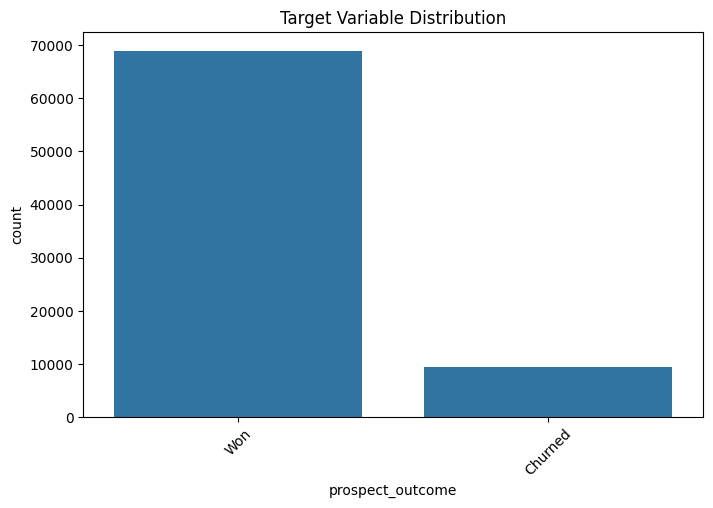

In [249]:
# EDA and Feature Engineering for High-Dimensional Data

# First, let's work on the pre-encoded dataframe for better interpretability in EDA
df_eda = df_filtered.copy()

# Identify target variable
target = 'prospect_outcome'
print("Target distribution:")
print(df_eda[target].value_counts())
print(df_eda[target].value_counts(normalize=True))

# Plot target distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_eda, x=target)
plt.title('Target Variable Distribution')
plt.xticks(rotation=45)
plt.show()

Number of numerical columns: 31
Numerical columns: ['sustainability_score', 'total_renewal_score_new', 'last_years_price', 'auto_renewal_score', 'status_scores', 'anchoring_score', 'tenure_scores', 'current_anchorings', 'payment_timeframe', 'renewal_score_at_release', 'tenure_years', 'starting_net', 'starting_membership_net', 'starting_package_net', 'starting_pqq_net', 'membership_net', 'package_net', 'pqqnet', 'total_amount', 'last_total_net_paid', 'last_connections', 'is_first_year', 'has_discount', 'discount_pct', 'call_number', 'crm_contractor_sentiment_score', 'crm_agent_chase_count', 'crm_auto_renewal_status', 'cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score', 'cc_contractor_sentiment_overall_score']
       sustainability_score  total_renewal_score_new  last_years_price  \
count          78325.000000             78325.000000      78325.000000   
mean               8.586275                41.994344       1174.714683   
std                0.687768          

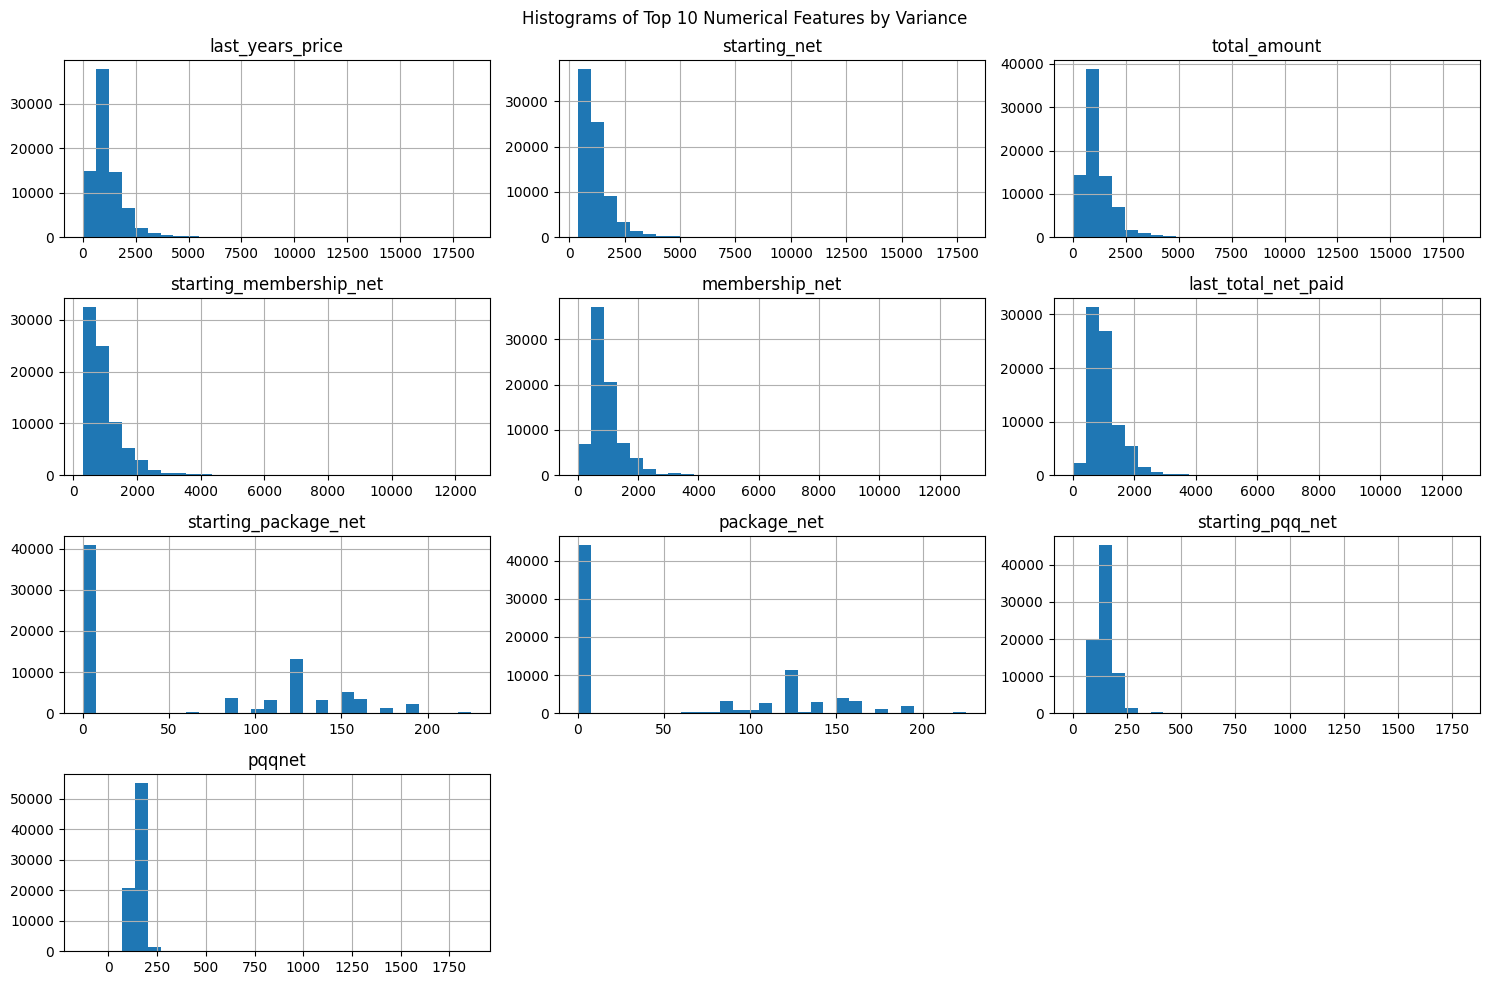

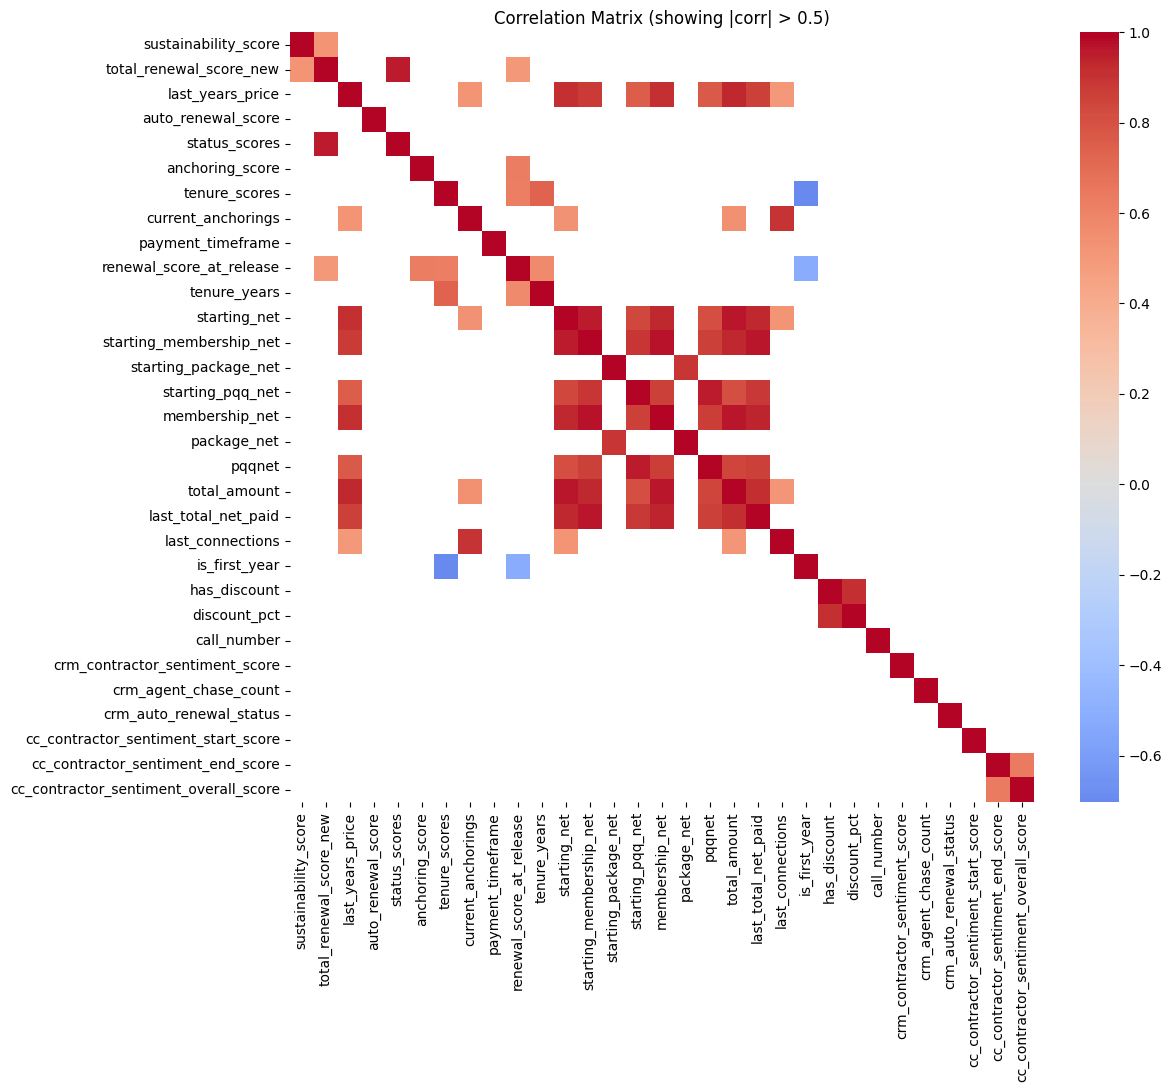

In [250]:
# Numerical features EDA
num_cols = df_eda.select_dtypes(include=['int64', 'float64']).columns
print(f"Number of numerical columns: {len(num_cols)}")
print("Numerical columns:", list(num_cols))

# Summary statistics
print(df_eda[num_cols].describe())

# Histograms for numerical features (top 10 by variance to avoid overload)
top_num = df_eda[num_cols].var().sort_values(ascending=False).head(10).index
df_eda[top_num].hist(figsize=(15, 10), bins=30)
plt.suptitle('Histograms of Top 10 Numerical Features by Variance')
plt.tight_layout()
plt.show()

# Correlation matrix for numerical features (heatmap for top correlated)
corr_matrix = df_eda[num_cols].corr()
plt.figure(figsize=(12, 10))
# Show only correlations > 0.5 or < -0.5
mask = (corr_matrix.abs() < 0.5)
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (showing |corr| > 0.5)')
plt.show()

C:\Users\GauravRathore\AppData\Local\Temp\ipykernel_9060\3860149350.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_eda.select_dtypes(include=['object', 'category']).columns


Number of categorical columns: 78

price_range_mentioned (uniques: 765)
price_range_mentioned
Not Discussed    46802
Unknown          29546
589.0               71
899.0               20
140.0               20
80.0                18
345.0               18
689.0               17
774.0               16
559.0               16
Name: count, dtype: int64

last_renewal (uniques: 558)
last_renewal
2024-02-01    3826
2023-10-01    3600
2024-01-01    3533
2023-11-01    3520
2024-11-01    3475
2023-09-01    3453
2024-10-01    3405
2024-09-01    3377
2023-07-01    3314
2023-05-01    3266
Name: count, dtype: int64

last_band (uniques: 14)
last_band
Band B     18881
Band C1    15351
Band D     12542
Band C2    10487
Band E      6437
Band F1     4073
Band F2     2383
Band G      2122
Band A      2086
Band F      1863
Name: count, dtype: int64

band (uniques: 13)
band
Band B     18783
Band C1    15008
Band D     12740
Band C2    10121
Band E      6794
Band F1     5441
Band F2     3164
Band G      2156


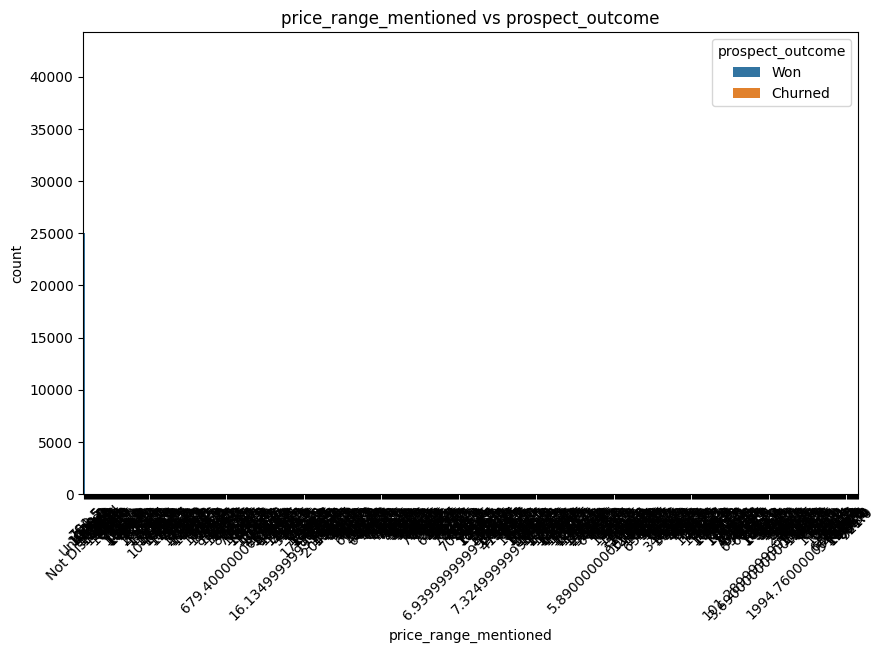

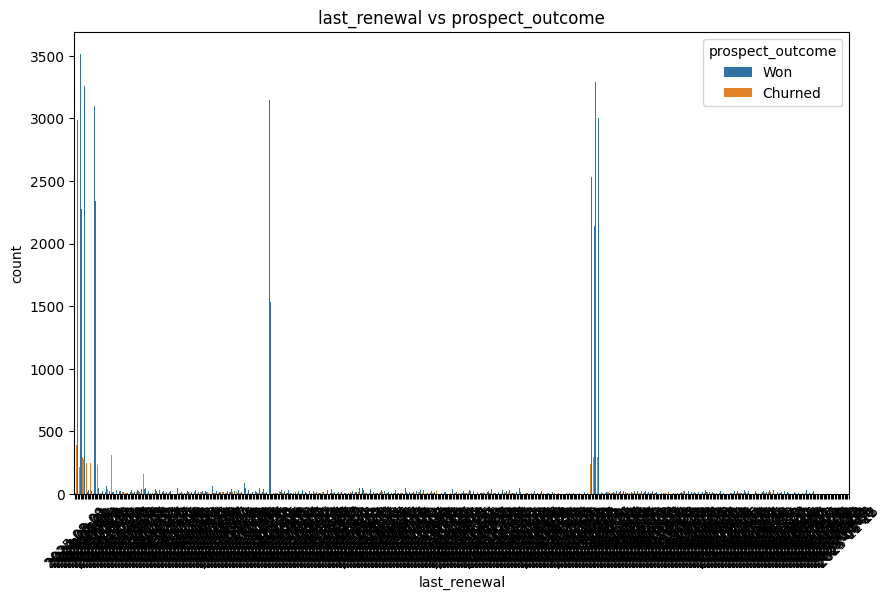

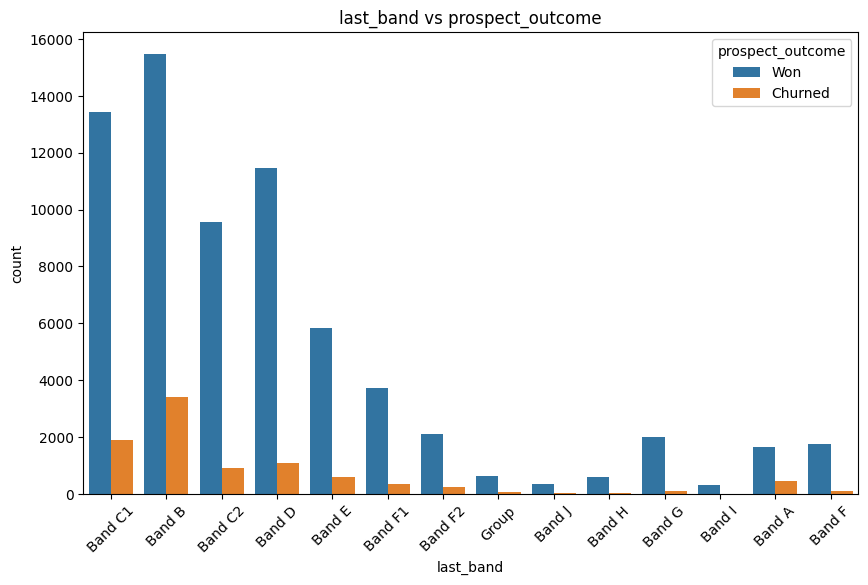

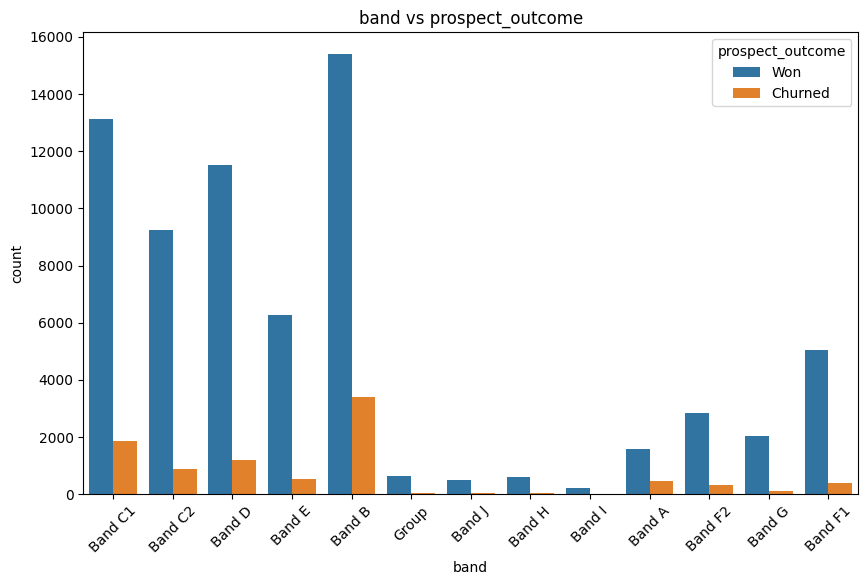

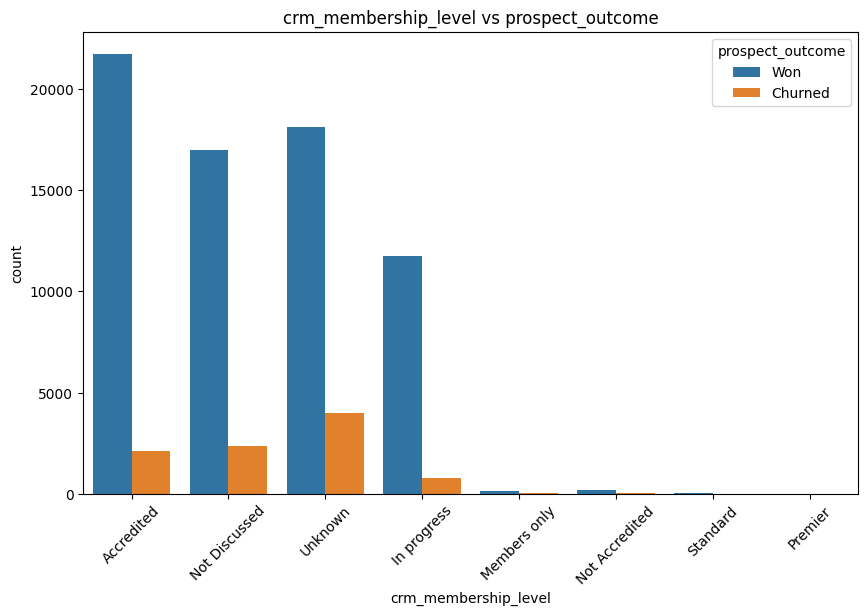

In [251]:
# Categorical features EDA
cat_cols = df_eda.select_dtypes(include=['object', 'category']).columns
print(f"Number of categorical columns: {len(cat_cols)}")

# Value counts for categorical features (top 5 by unique count)
top_cat = sorted(cat_cols, key=lambda x: df_eda[x].nunique(), reverse=True)[:5]
for col in top_cat:
    print(f"\n{col} (uniques: {df_eda[col].nunique()})")
    print(df_eda[col].value_counts().head(10))

# Bivariate: Target vs Categorical (for top 5)
for col in top_cat:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_eda, x=col, hue=target)
    plt.title(f'{col} vs {target}')
    plt.xticks(rotation=45)
    plt.legend(title=target)
    plt.show()